# Analisis Sentimen dengan IndoBERTweet


## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Install Library

In [ ]:
!pip install transformers datasets evaluate emoji scikit-learn accelerate optuna -U -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.7 MB/s eta 0:00:00


## Konfigurasi

In [ ]:
FILE_PATH        = '/content/drive/MyDrive/Tugas Akhir/inset/data-bismillah.xlsx'
OUTPUT_DIR       = '/content/drive/MyDrive/Tugas Akhir/model_indobertweet'
RESULT_DIR       = '/content/drive/MyDrive/Tugas Akhir/indobertweet/best_model'


## Import Library

In [ ]:
import re, os

import emoji
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (f1_score, accuracy_score,
                             confusion_matrix, classification_report)

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed,
)
import evaluate

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

## Load & Persiapan Data

In [ ]:
df = pd.read_excel(FILE_PATH, usecols=['id', 'text', 'label'])
df = df.rename(columns={'label': 'sentimen'})
df['sentimen'] = df['sentimen'].astype(str).str.strip().str.lower()
df = df[~df['sentimen'].isin(['neutral', 'netral'])]
df = df.dropna(subset=['text', 'sentimen'])
df = df[['id', 'text', 'sentimen']].reset_index(drop=True)

print(f"Total data  : {len(df)}")
print(df['sentimen'].value_counts())
df.head()

Total data  : 4618
sentimen
negative    3480
positive    1138
Name: count, dtype: int64


,id,text,sentimen
0,1,"Polisi tenan i kon niru kinerja ne polisi skena i lho, lugas dan tegas",negative
1,4,Semoga aplikasi pengaduan ini bisa menyempurnakan kinerja Polri.\n.\n#polripresisi #polisi #polri #PolisiBaik #Viral #fyp\n.\n.\n#DimanaNadia Di Ambang Kematian\nJackie Chan Mario Dandy https://t.co/JJ1QW1DWsi,positive
2,5,"@IUlilyy @bening_93 Semua orang yang pernah kehilangan motor gak bakal pernah ngakuin kinerja polisi 😂 kakak saya juga keilangan motor, mana motor baru lagi, lapor polisi? Gak guna wkwkwk",negative
3,6,@septjunior Kenapa polisi kita beda sm yg di 86 ya kinerja nya,negative
4,7,setelah semua gak diterima beneran gak mau percaya sama polisi lagi. sorry but I really meragukan kinerja polisi sekarang. kalo emang gaada bukti nota sepeda yang nunjukin kepemilikan ya okay deh tapi at least dicatet kalo ada laporan kehilangan nah ini dicatet aja enggak..,negative


## Preprocessing Tweet

In [ ]:
def find_url(string):
    regex = r"""(?i)\b((?:https?://|www\d{0,3}[.]|[a-z0-9.\-]+[.][a-z]{2,4}/)(?:[^\s()<>]+|\(([^\s()<>]+|(\([^\s()<>]+\)))*\))+(?:\(([^\s()<>]+|(\([^\s()<>]+\)))*\)|[^\s`!()\[\]{};:\'\".,<>?«»\u201c\u201d\u2018\u2019]))"""
    return [x[0] for x in re.findall(regex, string)]

def preprocess_tweet(tweet):
    tweet = emoji.demojize(str(tweet)).lower()
    tokens = []
    for word in tweet.split():
        if word[0] == '@' or word == '[username]':
            tokens.append('@USER')
        elif find_url(word) or word in ('httpurl', '[url]'):
            tokens.append('HTTPURL')
        else:
            tokens.append(word)
    return ' '.join(tokens)

df['post'] = df['text'].apply(preprocess_tweet)
df = df[['id', 'post', 'sentimen']].copy()
df.head()

,id,post,sentimen
0,1,"polisi tenan i kon niru kinerja ne polisi skena i lho, lugas dan tegas",negative
1,4,semoga aplikasi pengaduan ini bisa menyempurnakan kinerja polri. . #polripresisi #polisi #polri #polisibaik #viral #fyp . . #dimananadia di ambang kematian jackie chan mario dandy HTTPURL,positive
2,5,"@USER @USER semua orang yang pernah kehilangan motor gak bakal pernah ngakuin kinerja polisi :face_with_tears_of_joy: kakak saya juga keilangan motor, mana motor baru lagi, lapor polisi? gak guna wkwkwk",negative
3,6,@USER kenapa polisi kita beda sm yg di 86 ya kinerja nya,negative
4,7,setelah semua gak diterima beneran gak mau percaya sama polisi lagi. sorry but i really meragukan kinerja polisi sekarang. kalo emang gaada bukti nota sepeda yang nunjukin kepemilikan ya okay deh tapi at least dicatet kalo ada laporan kehilangan nah ini dicatet aja enggak..,negative


## Label Encoding

In [ ]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentimen'])

label2id = {label: int(idx) for idx, label in enumerate(label_encoder.classes_)}
id2label = {int(idx): label for idx, label in enumerate(label_encoder.classes_)}

print(f"Kelas   : {label_encoder.classes_}")
print(f"label2id: {label2id}")
print(f"id2label: {id2label}")
print(f"\nDistribusi label:")
print(df['label'].value_counts())
print(f"\nRasio: {df['label'].value_counts().min() / df['label'].value_counts().max():.2f}")

Kelas   : ['negative' 'positive']
label2id: {'negative': 0, 'positive': 1}
id2label: {0: 'negative', 1: 'positive'}

Distribusi label:
label
0    3480
1    1138
Name: count, dtype: int64

Rasio: 0.33


## Setting IndoBERTweet

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4618 entries, 0 to 4617
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        4618 non-null   int64 
 1   post      4618 non-null   object
 2   sentimen  4618 non-null   object
 3   label     4618 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 144.4+ KB


### Load Tokenizer

In [ ]:
MODEL_NAME       = "indolem/indobertweet-base-uncased"
MAX_LENGTH       = 128

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
print(f"Tokenizer loaded: {MODEL_NAME}")


def tokenize_function(examples):
    return tokenizer(
        examples['post'],
        padding='max_length',
        max_length=MAX_LENGTH,
        truncation=True,
    )

config.json:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/235k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded: indolem/indobertweet-base-uncased


In [ ]:
NUM_LABELS = 2
TEST_SIZE  = 0.2
VAL_SIZE   = 0.1
BASE_SEED  = 2021


In [ ]:
import pandas as pd
import os
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True
)

parameter_data = []
total_params = 0

# Sekarang variabel 'model' sudah dikenali
for name, param in model.named_parameters():

    # Format Dimensi (misal: "50000 × 768")
    dimensi_list = [str(dim) for dim in param.shape]
    dimensi_str = " × ".join(dimensi_list)

    # Jumlah parameter
    jumlah_param = param.numel()
    total_params += jumlah_param

    # Format angka (titik sebagai pemisah ribuan)
    jumlah_param_format = f"{jumlah_param:,}".replace(',', '.')

    parameter_data.append({
        'Nama Parameter (Tensor)': name,
        'Dimensi': dimensi_str,
        'Jumlah Parameter': jumlah_param_format,
        'Requires Gradient': param.requires_grad
    })

# Konversi ke DataFrame
df_params = pd.DataFrame(parameter_data)

# Buat baris Total Parameter
baris_total = pd.DataFrame({
    'Nama Parameter (Tensor)': ['Total Parameter'],
    'Dimensi': [''],
    'Jumlah Parameter': [f"{total_params:,}".replace(',', '.')],
    'Requires Gradient': ['']
})

# Gabungkan baris total
df_params = pd.concat([df_params, baris_total], ignore_index=True)

# Simpan ke Excel
excel_path = os.path.join(RESULT_DIR, 'arsitektur_parameter_model.xlsx')
df_params.to_excel(excel_path, index=False)
print(f"Tabel parameter berhasil disimpan di: {excel_path}\n")

# Tampilkan di layar
display(df_params)

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Tabel parameter berhasil disimpan di: /content/drive/MyDrive/Tugas Akhir/indobertweet/best_model/arsitektur_parameter_model.xlsx



,Nama Parameter (Tensor),Dimensi,Jumlah Parameter,Requires Gradient
0,bert.embeddings.word_embeddings.weight,31923 × 768,24.516.864,True
1,bert.embeddings.position_embeddings.weight,512 × 768,393.216,True
2,bert.embeddings.token_type_embeddings.weight,2 × 768,1.536,True
3,bert.embeddings.LayerNorm.weight,768,768,True
4,bert.embeddings.LayerNorm.bias,768,768,True
...,...,...,...,...
197,bert.pooler.dense.weight,768 × 768,589.824,True
198,bert.pooler.dense.bias,768,768,True
199,classifier.weight,2 × 768,1.536,True
200,classifier.bias,2,2,True


### Siapkan Data Untuk Training

In [ ]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

# 1. Split awal → train+val (80%) dan test (20%)
df_trainval, df_test = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=BASE_SEED,
    stratify=df['label']
)

# 2. validation (≈10% dari total data)
val_ratio = VAL_SIZE / (1 - TEST_SIZE)
df_train, df_val = train_test_split(
    df_trainval,
    test_size=val_ratio,
    random_state=BASE_SEED,
    stratify=df_trainval['label']
)

print(f"Train      : {len(df_train)} baris")
print(f"Validation : {len(df_val)} baris")
print(f"Test       : {len(df_test)} baris")
print(f"Total      : {len(df_train)+len(df_val)+len(df_test)} baris")

# 3. Konversi ke HuggingFace DatasetDict
raw_datasets = DatasetDict({
    'train'     : Dataset.from_pandas(df_train),
    'validation': Dataset.from_pandas(df_val),
    'test'      : Dataset.from_pandas(df_test),
})

# 4. Tokenisasi
tokenized = raw_datasets.map(tokenize_function, batched=True)

# 5. Hapus kolom non-model (jaga 'label')
cols_to_remove = [c for c in tokenized['train'].column_names
                  if c not in ('input_ids', 'attention_mask', 'label')]
tokenized = tokenized.remove_columns(cols_to_remove)
tokenized.set_format('torch')

print(f"\nKolom akhir: {tokenized['train'].column_names}")


Train      : 3232 baris
Validation : 462 baris
Test       : 924 baris
Total      : 4618 baris


Map:   0%|          | 0/3232 [00:00<?, ? examples/s]

Map:   0%|          | 0/462 [00:00<?, ? examples/s]

Map:   0%|          | 0/924 [00:00<?, ? examples/s]


Kolom akhir: ['label', 'input_ids', 'attention_mask']


In [ ]:
# Membuat tabel kontingensi untuk melihat sebaran label di setiap subset data
import pandas as pd

# Tambahkan kolom penanda subset pada masing-masing dataframe
df_train['subset'] = 'Train'
df_val['subset'] = 'Validation'
df_test['subset'] = 'Test'

# Gabungkan kembali untuk kebutuhan pengecekan distribusi
df_all_splits = pd.concat([df_train, df_val, df_test])

# Tampilkan tabel rincian distribusi kelas
tabel_distribusi = pd.crosstab(df_all_splits['subset'], df_all_splits['label'], margins=True, margins_name='Total')
display(tabel_distribusi)

label,0,1,Total
subset,,,
Test,696,228,924
Train,2436,796,3232
Validation,348,114,462
Total,3480,1138,4618


### Fungsi Evaluasi Metrics

In [ ]:
import evaluate

accuracy_metric = evaluate.load('accuracy')
f1_metric       = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)['accuracy']
    f1  = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average='macro'
    )['f1']
    return {'accuracy': acc, 'f1': f1}

ModuleNotFoundError: No module named 'evaluate'

### Hyperparameter Tuning


In [ ]:
import os, gc, shutil, optuna, pandas as pd, torch
from transformers import (
    AutoModelForSequenceClassification, TrainingArguments,
    Trainer, set_seed,
)

# FASE 1 — OPTUNA: Pencarian Hyperparameter Terbaik (TPE Search, Disk-Efficient, Maximize F1)

SEARCH_LR    = [5e-5, 3e-5, 2e-5]
SEARCH_BATCH = [16, 32]
SEARCH_EPOCH = [2, 3, 4]

def objective(trial):
    lr         = trial.suggest_categorical('lr',         SEARCH_LR)
    batch_size = trial.suggest_categorical('batch_size', SEARCH_BATCH)
    epoch      = trial.suggest_categorical('epoch',      SEARCH_EPOCH)

    set_seed(BASE_SEED)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )

    trial_output_dir  = os.path.join(RESULT_DIR, f'optuna_trial_{trial.number}')
    trial_logging_dir = os.path.join('./logs', f'trial_{trial.number}')

    args = TrainingArguments(
        output_dir=trial_output_dir,
        num_train_epochs=epoch,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        eval_strategy='epoch',
        save_strategy='epoch',
        logging_strategy='epoch',
        load_best_model_at_end=False,
        save_total_limit=1,
        fp16=True,
        logging_dir=trial_logging_dir,
        report_to='none',
    )

    trainer = Trainer(
        model=model, args=args,
        train_dataset=tokenized['train'],
        eval_dataset=tokenized['validation'],
        compute_metrics=compute_metrics,
    )

    trainer.train()
    eval_result = trainer.evaluate()

    # Simpan metrik lain ke dalam atribut user Optuna agar tetap tercatat di DataFrame
    trial.set_user_attr('eval_accuracy', eval_result.get('eval_accuracy', 0))
    trial.set_user_attr('eval_loss', eval_result.get('eval_loss', 0))

    # Bersihkan SEMUA artefak trial ini (checkpoint + logging dir) — hemat disk
    for d in (trial_output_dir, trial_logging_dir):
        if os.path.exists(d):
            shutil.rmtree(d, ignore_errors=True)

    # Bebaskan memori GPU antar trial
    del model, trainer
    gc.collect()
    torch.cuda.empty_cache()

    return eval_result.get('eval_f1', 0)

N_TRIALS = 10

print('Pencarian Hyperparameter dengan Optuna (TPE Search - Maximize F1)')

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=BASE_SEED),
)
study.optimize(objective, n_trials=N_TRIALS)

BEST_LR    = study.best_params['lr']
BEST_BATCH = study.best_params['batch_size']
BEST_EPOCH = study.best_params['epoch']

# Ambil metrik, urutkan berdasarkan 'Trial'
df_trials = pd.DataFrame([
    {'Trial': t.number,
     'Val_F1': round(t.value, 4) if t.value is not None else None,
     'Val_Acc': round(t.user_attrs.get('eval_accuracy', 0), 4),
     'Val_Loss': round(t.user_attrs.get('eval_loss', 0), 4),
     'LR': t.params.get('lr'),
     'BatchSize': t.params.get('batch_size'),
     'Epoch': t.params.get('epoch'),
     'Status': t.state.name}
    for t in study.trials if t.state.name == 'COMPLETE'
]).sort_values('Trial', ascending=True)

df_trials.to_excel(os.path.join(RESULT_DIR, 'optuna_all_trials.xlsx'), index=False)

print(f'\nVal F1 Terbaik : {study.best_value:.4f}')
print(f'LR             : {BEST_LR}')
print(f'Batch Size     : {BEST_BATCH}')
print(f'Epoch          : {BEST_EPOCH}')

[I 2026-07-08 17:37:44,710] A new study created in memory with name: no-name-0a9a9364-a017-4769-b738-a2748209bd8f


Pencarian Hyperparameter dengan Optuna (TPE Search - Maximize F1)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[trans

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.284182,0.214726,0.924242,0.887922
2,0.133801,0.200546,0.932900,0.907238
3,0.071530,0.256659,0.941558,0.921624
4,0.037378,0.272309,0.939394,0.918958


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.128873,0.273233,2,0.935065,0.910511


[I 2026-07-08 17:47:46,011] Trial 9 finished with value: 0.9105113636363636 and parameters: {'lr': 5e-05, 'batch_size': 16, 'epoch': 2}. Best is trial 3 with value: 0.9309348216065378.



Val F1 Terbaik : 0.9309
LR             : 5e-05
Batch Size     : 16
Epoch          : 3


Grafik histori Optuna yang baru berhasil disimpan di: /content/drive/MyDrive/Tugas Akhir/indobertweet/best_model/plot_optuna_history.png


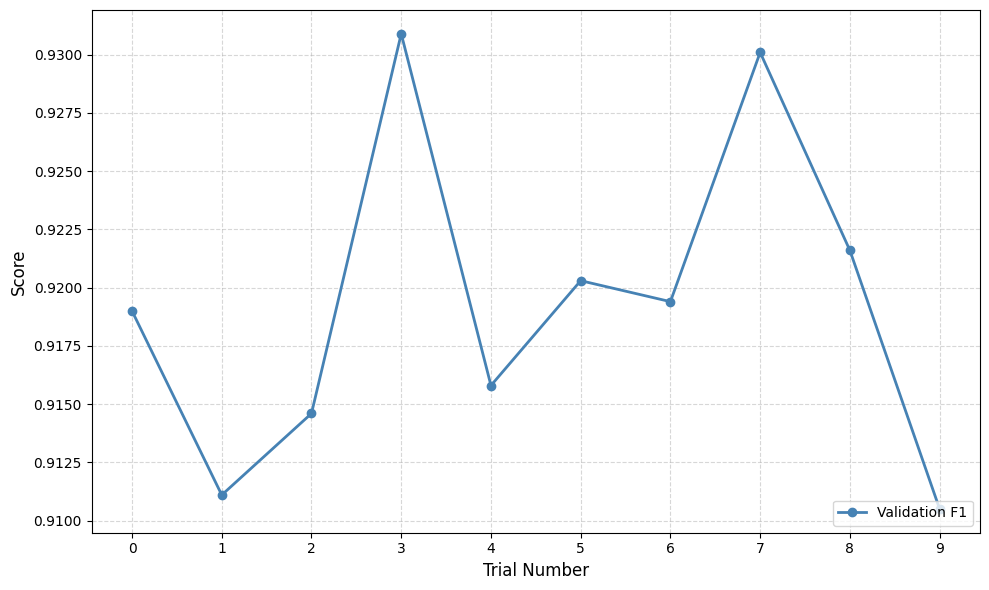

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

excel_path = os.path.join(RESULT_DIR, 'optuna_all_trials.xlsx')
df_trials = pd.read_excel(excel_path)
df_trials['Val_F1'] = df_trials['Val_F1'].fillna(0.0)

# 2. Ambil data yang sudah diperbaiki
trials = df_trials['Trial'].values
f1_scores = df_trials['Val_F1'].values

# 3. Plot ulang grafiknya
plt.figure(figsize=(10, 6))

plt.plot(trials, f1_scores, marker='o', color='steelblue', label='Validation F1', linewidth=2, markersize=6)

plt.xlabel('Trial Number', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(trials)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Timpa/simpan ulang gambar plotnya
optuna_plot_path = os.path.join(RESULT_DIR, 'plot_optuna_history.png')
plt.savefig(optuna_plot_path, dpi=150, bbox_inches='tight')
print(f"Grafik histori Optuna yang baru berhasil disimpan di: {optuna_plot_path}")

plt.show()

## Training Hyperparaneter Terbaik

In [ ]:
import os
import pandas as pd
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed
)

print("="*60)
print("FINAL MODEL TRAINING (Best Hyperparameter dari TPE)")
print("="*60)
print(f"Learning Rate : {BEST_LR}")
print(f"Batch Size    : {BEST_BATCH}")
print(f"Epoch         : {BEST_EPOCH}")
print("="*60)

set_seed(BASE_SEED)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

training_args = TrainingArguments(
    output_dir=os.path.join(RESULT_DIR, "final_model"),

    learning_rate=BEST_LR,
    num_train_epochs=BEST_EPOCH,

    per_device_train_batch_size=BEST_BATCH,
    per_device_eval_batch_size=BEST_BATCH,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=False,
    save_total_limit=1,

    fp16=True,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    compute_metrics=compute_metrics,
)

trainer.train()

val_result = trainer.evaluate()

print("\nTraining selesai.")
print(f"Validation F1  : {val_result['eval_f1']:.4f}")
print(f"Validation Acc : {val_result['eval_accuracy']:.4f}")

history_df = pd.DataFrame(trainer.state.log_history)
history_df.to_excel(
    os.path.join(RESULT_DIR, "training_history_final_model.xlsx"),
    index=False
)

prediction_output = trainer.predict(tokenized["test"])

print("\n===== FINAL TEST RESULT =====")
print(f"Accuracy  : {prediction_output.metrics['test_accuracy']:.4f}")
print(f"F1 Score  : {prediction_output.metrics['test_f1']:.4f}")

df_result = pd.DataFrame({
    "Learning Rate":[BEST_LR],
    "Batch Size":[BEST_BATCH],
    "Epoch":[BEST_EPOCH],
    "Validation F1":[val_result['eval_f1']],
    "Test Accuracy":[prediction_output.metrics["test_accuracy"]],
    "Test F1":[prediction_output.metrics["test_f1"]],
})
df_result.to_excel(
    os.path.join(RESULT_DIR, "final_result_model.xlsx"),
    index=False
)

print("\nSemua hasil berhasil disimpan.")

FINAL MODEL TRAINING (Best Hyperparameter dari TPE)
Learning Rate : 5e-05
Batch Size    : 16
Epoch         : 3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.252222,0.235081,0.919913,0.884826
2,0.118622,0.252954,0.943723,0.926428
3,0.055285,0.270947,0.948052,0.930935


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.055285,0.270947,3,0.948052,0.930935



Training selesai.
Validation F1  : 0.9309
Validation Acc : 0.9481



===== FINAL TEST RESULT =====
Accuracy  : 0.9340
F1 Score  : 0.9103

Semua hasil berhasil disimpan.


Checkpoint yang dipakai: /content/drive/MyDrive/Tugas Akhir/indobertweet/best_model/final_model/checkpoint-606


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


=== CLASSIFICATION REPORT (FINAL MODEL — Best Optuna Hyperparameter) ===
              precision    recall  f1-score   support

    negative     0.9516    0.9612    0.9564       696
    positive     0.8778    0.8509    0.8641       228

    accuracy                         0.9340       924
   macro avg     0.9147    0.9060    0.9103       924
weighted avg     0.9334    0.9340    0.9336       924


Confusion Matrix disimpan di:
/content/drive/MyDrive/Tugas Akhir/indobertweet/best_model/confusion_matrix_final_model.png


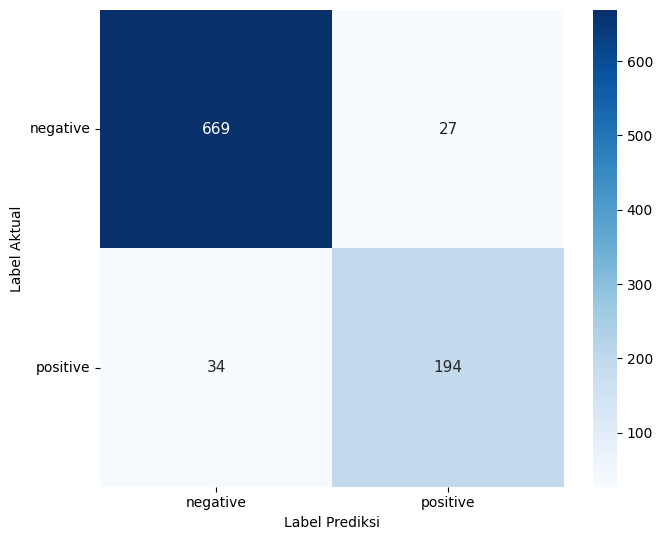

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from transformers import AutoModelForSequenceClassification, Trainer

# AMBIL CHECKPOINT TERAKHIR (= akhir BEST_EPOCH, karena load_best_model_at_end=False)

final_model_folder = os.path.join(RESULT_DIR, "final_model")
checkpoint_dirs = glob.glob(os.path.join(final_model_folder, "checkpoint-*"))
best_checkpoint = sorted(checkpoint_dirs, key=lambda p: int(p.split('-')[-1]))[-1]

print(f"Checkpoint yang dipakai: {best_checkpoint}")

# LOAD MODEL

best_model = AutoModelForSequenceClassification.from_pretrained(best_checkpoint)
eval_trainer = Trainer(model=best_model)

# PREDIKSI TEST SET

predictions = eval_trainer.predict(tokenized["test"])

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

labels = [id2label[i] for i in sorted(id2label.keys())]

# CLASSIFICATION REPORT

print(f"\n=== CLASSIFICATION REPORT (FINAL MODEL — Best Optuna Hyperparameter) ===")
print(
    classification_report(
        y_true, y_pred,
        target_names=labels,
        digits=4,
        zero_division=0
    )
)

# CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels,
    annot_kws={"size": 11}
)
plt.xlabel("Label Prediksi")
plt.ylabel("Label Aktual")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = os.path.join(RESULT_DIR, "confusion_matrix_final_model.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")

print(f"\nConfusion Matrix disimpan di:")
print(cm_path)

plt.show()

In [ ]:
import os
import pandas as pd
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    TrainerCallback,
    set_seed
)

FINAL_EPOCHS = 10

set_seed(BASE_SEED)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

training_args = TrainingArguments(
    output_dir=os.path.join(RESULT_DIR, "plot_model"),

    learning_rate=BEST_LR,
    num_train_epochs=FINAL_EPOCHS,

    per_device_train_batch_size=BEST_BATCH,
    per_device_eval_batch_size=BEST_BATCH,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True,

    save_total_limit=1,
    fp16=True,
    report_to="none",
)

class TrainMetricsCallback(TrainerCallback):
    def __init__(self, train_dataset):
        self.train_dataset = train_dataset
        self.train_metrics_history = []

    def on_epoch_end(self, args, state, control, **kwargs):
        trainer_ref = kwargs['model']
        temp_trainer = Trainer(
            model=trainer_ref,
            args=TrainingArguments(
                output_dir="./tmp_train_eval",
                per_device_eval_batch_size=BEST_BATCH,
                fp16=True,
                report_to="none",
            ),
            eval_dataset=self.train_dataset,
            compute_metrics=compute_metrics,
        )
        result = temp_trainer.evaluate()
        self.train_metrics_history.append({
            'epoch': state.epoch,
            'train_f1': result.get('eval_f1', 0),
            'train_accuracy': result.get('eval_accuracy', 0),
        })
        del temp_trainer

train_metrics_callback = TrainMetricsCallback(tokenized["train"])

trainer_plot = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    compute_metrics=compute_metrics,
    callbacks=[train_metrics_callback],
)

trainer_plot.train()

history_df = pd.DataFrame(trainer_plot.state.log_history)
train_metrics_df = pd.DataFrame(train_metrics_callback.train_metrics_history)

history_df.to_excel(os.path.join(RESULT_DIR, "training_history_10_epoch.xlsx"), index=False)
train_metrics_df.to_excel(os.path.join(RESULT_DIR, "train_metrics_history_10_epoch.xlsx"), index=False)

print("History untuk plotting disimpan.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.263034,0.210580,0.926407,0.901591
2,0.132331,0.352794,0.930736,0.912261
3,0.064264,0.322985,0.932900,0.912519
4,0.023054,0.403453,0.939394,0.919881
5,0.013162,0.410652,0.943723,0.924304
6,0.002389,0.439786,0.943723,0.926428
7,0.002271,0.434878,0.943723,0.925604
8,0.003414,0.479051,0.939394,0.918958
9,0.000097,0.469199,0.945887,0.928262
10,0.000058,0.472583,0.945887,0.928262


Training Loss,Validation Loss,Step,Accuracy,F1
No log,0.106550,0,0.968131,0.957171


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Training Loss,Validation Loss,Step,Accuracy,F1
No log,0.000036,0,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,F1
No log,0.000033,0,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

History untuk plotting disimpan.


Grafik F1/Acc disimpan di: /content/drive/MyDrive/Tugas Akhir/indobertweet/best_model/plot_val_f1_acc_10_epoch.png


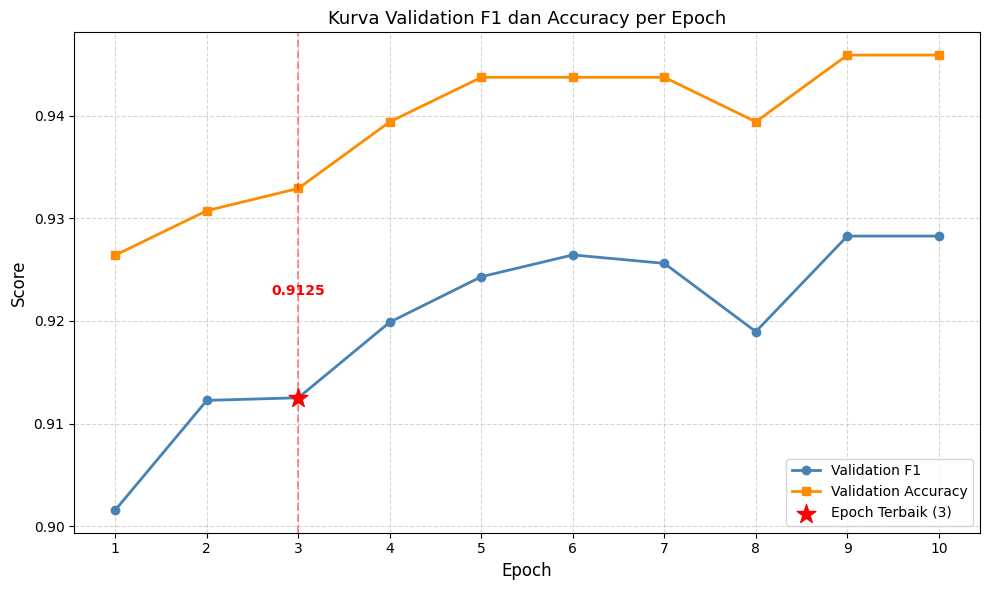

Grafik loss disimpan di: /content/drive/MyDrive/Tugas Akhir/indobertweet/best_model/plot_train_val_loss_10_epoch.png


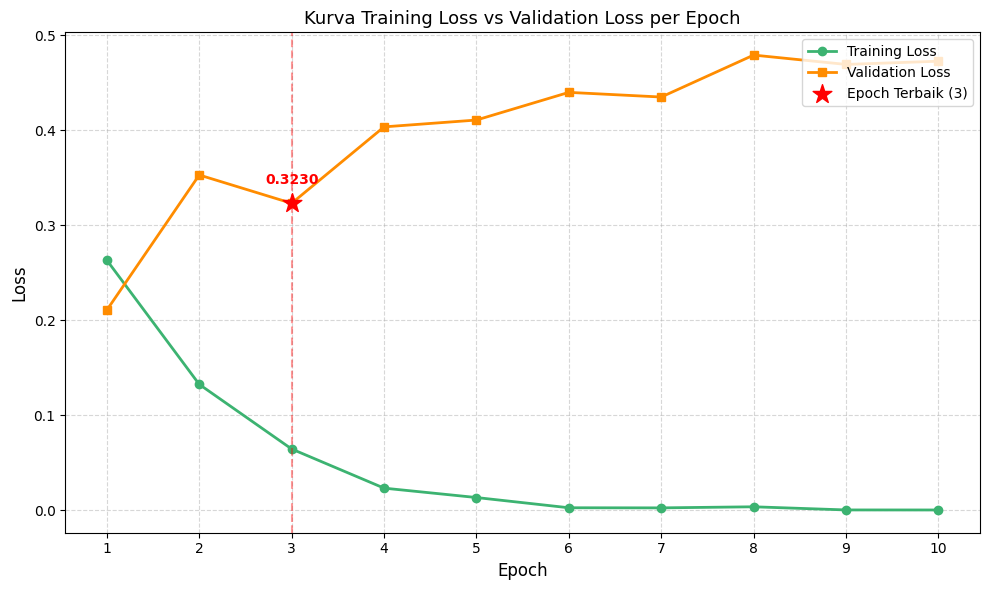

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Load history training 10 epoch
excel_path = os.path.join(RESULT_DIR, "training_history_10_epoch.xlsx")
history_df = pd.read_excel(excel_path)

# Baris evaluasi (Validation Loss, Accuracy, F1)
eval_df = history_df[history_df['eval_f1'].notna()].sort_values('epoch')
val_epochs = eval_df['epoch'].values
val_f1     = eval_df['eval_f1'].values
val_loss   = eval_df['eval_loss'].values
val_acc    = eval_df['eval_accuracy'].values

# Baris training loss
train_loss_df = history_df[history_df['loss'].notna()].sort_values('epoch')
train_loss_epochs = train_loss_df['epoch'].values
train_loss_vals    = train_loss_df['loss'].values

# Epoch terbaik — ditetapkan dari hasil BEST_EPOCH Optuna, bukan argmax F1 di run 10-epoch ini
best_epoch_val = BEST_EPOCH
best_idx       = list(val_epochs).index(best_epoch_val)
best_f1_val    = val_f1[best_idx]
best_loss_val  = val_loss[best_idx]

# ── PLOT 1: Validation F1 dan Accuracy per Epoch ──
plt.figure(figsize=(10, 6))
plt.plot(val_epochs, val_f1, marker='o', color='steelblue', label='Validation F1', linewidth=2, markersize=6)
plt.plot(val_epochs, val_acc, marker='s', color='darkorange', label='Validation Accuracy', linewidth=2, markersize=6)

plt.scatter(best_epoch_val, best_f1_val, color='red', s=200, zorder=5, marker='*', label=f'Epoch Terbaik ({best_epoch_val})')
plt.axvline(x=best_epoch_val, color='red', linestyle='--', alpha=0.4)
plt.annotate(f'{best_f1_val:.4f}', xy=(best_epoch_val, best_f1_val),
             xytext=(best_epoch_val, best_f1_val + 0.01),
             ha='center', fontsize=10, fontweight='bold', color='red')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(val_epochs)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.title('Kurva Validation F1 dan Accuracy per Epoch', fontsize=13)
plt.tight_layout()

f1_plot_path = os.path.join(RESULT_DIR, 'plot_val_f1_acc_10_epoch.png')
plt.savefig(f1_plot_path, dpi=150, bbox_inches='tight')
print(f"Grafik F1/Acc disimpan di: {f1_plot_path}")
plt.show()

# ── PLOT 2: Training Loss vs Validation Loss per Epoch ──
plt.figure(figsize=(10, 6))
plt.plot(train_loss_epochs, train_loss_vals, marker='o', color='mediumseagreen', label='Training Loss', linewidth=2, markersize=6)
plt.plot(val_epochs, val_loss, marker='s', color='darkorange', label='Validation Loss', linewidth=2, markersize=6)

plt.scatter(best_epoch_val, best_loss_val, color='red', s=200, zorder=5, marker='*', label=f'Epoch Terbaik ({best_epoch_val})')
plt.axvline(x=best_epoch_val, color='red', linestyle='--', alpha=0.4)
plt.annotate(f'{best_loss_val:.4f}', xy=(best_epoch_val, best_loss_val),
             xytext=(best_epoch_val, best_loss_val + 0.02),
             ha='center', fontsize=10, fontweight='bold', color='red')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(val_epochs)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.title('Kurva Training Loss vs Validation Loss per Epoch', fontsize=13)
plt.tight_layout()

loss_plot_path = os.path.join(RESULT_DIR, 'plot_train_val_loss_10_epoch.png')
plt.savefig(loss_plot_path, dpi=150, bbox_inches='tight')
print(f"Grafik loss disimpan di: {loss_plot_path}")
plt.show()

## Simpan Hasil ke Excel

In [ ]:
os.makedirs(RESULT_DIR, exist_ok=True)

# ── Tabel per run ─────────────────────────────────────────────────────────
df_final.to_excel(os.path.join(RESULT_DIR, 'hasil_10run.xlsx'), index=False)

# ── Tabel ringkasan CI ────────────────────────────────────────────────────
df_summary = pd.DataFrame({
    'metric'  : ['F1 (binary)', 'Accuracy'],
    'mean'    : [round(f1_mean, 4),  round(acc_mean, 4)],
    'std'     : [round(f1_std, 4),   round(acc_std, 4)],
    'ci_low'  : [round(f1_ci_low, 4), round(acc_ci_low, 4)],
    'ci_high' : [round(f1_ci_high, 4), round(acc_ci_high, 4)],
    'min'     : [round(f1_scores.min(), 4), round(acc_scores.min(), 4)],
    'max'     : [round(f1_scores.max(), 4), round(acc_scores.max(), 4)],
    'n_runs'  : [NUM_RUNS, NUM_RUNS],
})
df_summary.to_excel(os.path.join(RESULT_DIR, 'summary_ci.xlsx'), index=False)

print("File tersimpan:")
print(f"  - {RESULT_DIR}hasil_10run.xlsx")
print(f"  - {RESULT_DIR}summary_ci.xlsx")
print(f"  - {RESULT_DIR}plot_10run_ci.png")
print()
print(df_summary.to_string(index=False))

NameError: name 'df_final' is not defined

In [ ]:
import re
import emoji
import pandas as pd
import torch
import os

# =========================================================
# 1. FUNGSI PREPROCESSING DARI ANDA
# =========================================================
def find_url(string):
    regex = r"""(?i)\b((?:https?://|www\d{0,3}[.]|[a-z0-9.\-]+[.][a-z]{2,4}/)(?:[^\s()<>]+|\(([^\s()<>]+|(\([^\s()<>]+\)))*\))+(?:\(([^\s()<>]+|(\([^\s()<>]+\)))*\)|[^\s`!()\[\]{};:\'\".,<>?«»\u201c\u201d\u2018\u2019]))"""
    return [x[0] for x in re.findall(regex, string)]

def preprocess_tweet(tweet):
    tweet = emoji.demojize(str(tweet)).lower()
    tokens = []
    for word in tweet.split():
        if word[0] == '@' or word == '[username]':
            tokens.append('@USER')
        elif find_url(word) or word in ('httpurl', '[url]'):
            tokens.append('HTTPURL')
        else:
            tokens.append(word)
    return ' '.join(tokens)

# =========================================================
# 2. TEKS MENTAH -> PREPROCESSING
# =========================================================
raw_text = """@ListyoSigitP 5% aj saya masih mikir², gmana caranya bisa 70 %.🤦

Blm prnh sejarahnya pelaku penipuan online ponzi ditangkap pihak kepolisian.

Coba buktikan kinerja polisi itu benar dan bisa dipercaya. Buktikan pak 🫡
👇

https://t.co/mQ07iwnOPp"""

# Terapkan fungsi preprocessing
sample_text = preprocess_tweet(raw_text)

# =========================================================
# 3. TOKENISASI & WORD EMBEDDING
# =========================================================
# Tokenisasi dengan panjang statis 128
encoded_input = tokenizer(sample_text, padding='max_length', truncation=True, max_length=128, return_tensors='pt')

token_ids = encoded_input['input_ids'][0].tolist()
attention_mask = encoded_input['attention_mask'][0].tolist()
tokens = tokenizer.convert_ids_to_tokens(token_ids)

# Ambil Word Embedding
model.eval()
input_tensor = encoded_input['input_ids'].to(model.device)
with torch.no_grad():
    word_embeddings = model.get_input_embeddings()(input_tensor)[0]
emb = word_embeddings.cpu().numpy()

# =========================================================
# 4. PEMBUATAN FORMAT SATU BARIS (STRING FORMATTING)
# =========================================================

# A. Hasil Preprocessing (Teks yang sudah dibersihkan)
prepro_str = repr(sample_text)

# B. WordPiece Tokenizer
t_awal = tokens[:11]
t_str = f"[{', '.join([repr(t) for t in t_awal])}, ..., '{tokenizer.sep_token}', ..., '{tokenizer.pad_token}'] 1×128"

# C. Token ID
id_awal = token_ids[:11]
id_str = f"[{', '.join(map(str, id_awal))}, ..., {tokenizer.sep_token_id}, ..., {tokenizer.pad_token_id}] 1×128"

# D. Attention Mask
mask_awal = attention_mask[:11]
mask_str = f"[{', '.join(map(str, mask_awal))}, ..., 1, ..., 0] 1×128"

# E. Word Embedding
def f_val(val):
    return f"{val:9.6f}".replace('.', ',')

mat_str = (
    f"({f_val(emb[0,0])}  {f_val(emb[0,1])}  ⋯  {f_val(emb[0,-2])}  {f_val(emb[0,-1])} \n"
    f" {f_val(emb[1,0])}  {f_val(emb[1,1])}  ⋯  {f_val(emb[1,-2])}  {f_val(emb[1,-1])} \n"
    f"        ⋮                ⋮         ⋱         ⋮                ⋮       \n"
    f" {f_val(emb[-2,0])}  {f_val(emb[-2,1])}  ⋯  {f_val(emb[-2,-2])}  {f_val(emb[-2,-1])} \n"
    f" {f_val(emb[-1,0])}  {f_val(emb[-1,1])}  ⋯  {f_val(emb[-1,-2])}  {f_val(emb[-1,-1])} ) 128×768"
)

# =========================================================
# 5. GABUNGKAN KE DATAFRAME & SIMPAN
# =========================================================

df_ringkasan = pd.DataFrame({
    "Komponen": ["Hasil Preprocessing", "WordPiece Tokenizer", "Token ID", "Attention Mask", "Word Embedding"],
    "Representasi_Satu_Baris": [prepro_str, t_str, id_str, mask_str, mat_str]
})

# Simpan ke Excel (Pastikan RESULT_DIR sudah Anda atur sebelumnya)
excel_path = os.path.join(RESULT_DIR, 'ringkasan_1_baris_custom_tweet_prepro.xlsx')
df_ringkasan.to_excel(excel_path, index=False)

print(f"File berhasil disimpan di: {excel_path}\n")

# Tampilkan representasi di layar
display(df_ringkasan)

File berhasil disimpan di: /content/drive/MyDrive/Tugas Akhir/indobertweet/best_model/ringkasan_1_baris_custom_tweet_prepro.xlsx



,Komponen,Representasi_Satu_Baris
0,Hasil Preprocessing,"'@USER 5% aj saya masih mikir², gmana caranya bisa 70 %.:person_facepalming: blm prnh sejarahnya pelaku penipuan online ponzi ditangkap pihak kepolisian. coba buktikan kinerja polisi itu benar dan bisa dipercaya. buktikan pak :saluting_face: :backhand_index_pointing_down: HTTPURL'"
1,WordPiece Tokenizer,"['[CLS]', '@', 'user', '5', '%', 'aj', 'saya', 'masih', 'mikir', '##²', ',', ..., '[SEP]', ..., '[PAD]'] 1×128"
2,Token ID,"[3, 36, 12287, 25, 9, 2740, 1731, 1855, 26518, 1219, 16, ..., 4, ..., 0] 1×128"
3,Attention Mask,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..., 1, ..., 0] 1×128"
4,Word Embedding,"( 0,022554 -0,011851 ⋯ 0,017866 0,027453 \n 0,022216 -0,013227 ⋯ 0,000764 -0,073802 \n ⋮ ⋮ ⋱ ⋮ ⋮ \n -0,088049 -0,069762 ⋯ -0,060957 -0,062292 \n -0,088049 -0,069762 ⋯ -0,060957 -0,062292 ) 128×768"


In [ ]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np

logits = predictions.predictions
y_true = predictions.label_ids
y_pred = np.argmax(logits, axis=-1)

# 2. Konversi Logits ke Probabilitas (Softmax)
probs = F.softmax(torch.tensor(logits), dim=-1).numpy()

input_ids = tokenized['test']['input_ids']
decoded_texts = [tokenizer.decode(ids, skip_special_tokens=True) for ids in input_ids]

# 4. Buat DataFrame untuk mempermudah analisis
df_analisis = pd.DataFrame({
    'Preprocessed_Post': decoded_texts,
    'True_Label_ID': y_true,
    'Pred_Label_ID': y_pred,
    'Prob_Negatif': probs[:, 0], # Asumsi index 0 = Negatif
    'Prob_Positif': probs[:, 1]  # Asumsi index 1 = Positif
})

# Format probabilitas menjadi string "[prob_negatif; prob_positif]"
df_analisis['Distribusi_Prediksi'] = df_analisis.apply(
    lambda row: f"[{row['Prob_Negatif']:.3f}; {row['Prob_Positif']:.3f}]", axis=1
)

# Mapping nama label agar mudah dibaca
df_analisis['True_Label'] = df_analisis['True_Label_ID'].map(id2label)
df_analisis['Prediksi_Label'] = df_analisis['Pred_Label_ID'].map(id2label)

# Sesuaikan 'positive' dan 'negative' dengan nama label di id2label Anda
false_negatives = df_analisis[
    (df_analisis['True_Label'].str.lower() == 'positive') &
    (df_analisis['Prediksi_Label'].str.lower() == 'negative')
]

# B. FALSE POSITIVE (Aktual Negatif, tapi ditebak Positif)
false_positives = df_analisis[
    (df_analisis['True_Label'].str.lower() == 'negative') &
    (df_analisis['Prediksi_Label'].str.lower() == 'positive')
]

# Tampilkan hasil untuk di-copy ke Word / Tugas Akhir
print(f"=== TOTAL FALSE NEGATIVE: {len(false_negatives)} ===")
display(false_negatives[['Preprocessed_Post', 'Distribusi_Prediksi', 'Prediksi_Label']].head(10))

print(f"\n=== TOTAL FALSE POSITIVE: {len(false_positives)} ===")
display(false_positives[['Preprocessed_Post', 'Distribusi_Prediksi', 'Prediksi_Label']].head(10))

# Opsional: Simpan ke Excel agar mudah dibaca dan di-copy ke laporan
df_analisis.to_excel(os.path.join(RESULT_DIR, 'analisis_error_prediksi.xlsx'), index=False)

=== TOTAL FALSE NEGATIVE: 34 ===


,Preprocessed_Post,Distribusi_Prediksi,Prediksi_Label
96,@ user polisi kinerja sesuai sumpah karir jalan ditempat yang kriminal sangat cepat. pimpinan mau bukti?,[0.991; 0.009],negative
113,"@ user survey membuktikan masyarakat puas pada kinerja polisi, tentara dan sipir diatas 80 %.",[0.819; 0.181],negative
143,"luar biasa kerjanya pak polisi, sudah saatnya pak prabowo harus mereformasi besar - besaran kepolisian mulai atasan sampai bawahan atas kinerja yg sangat lambat dalam menangani pagar laut sepanjang 30 httpurl",[1.000; 0.000],negative
170,"@ user "" lucu aja sih masa kinerja polisi dikira viral dulu bertindak, apa gak lihat beberapa kasus yang diungkap polri juga, tuh kayak pengukapan lab narkoba dimedan, ayo kita mendukung mereka bukan hanya bisa kritik² mereka aja, mereka juga manusia",[0.529; 0.471],negative
198,"@ user bgm pak, kinerja polisi di tuduh cawe2 dlm pemilu oleh politisi???",[0.999; 0.001],negative
277,"@ user hebat sekali ya pemerintah kita dalam melawan judi online. emang sesulit apa sih buat menutup website judi online itu? — - pertama, pemerintah blokir rekening bank yang kemungkinanan pernah terkoneksi dengan judi online. : face _ with _ rolling _ eyes : kedua, polisi merazia hp warga buat periksa apakah",[0.998; 0.002],negative
327,"@ user @ user polisi sering dituduh cuma gerak kalo kasus viral, kalian ga tau keringat darah tenaga apa yg di keluarin polisi tanpa di di viral kan dulu mereka punya cara sendiri buat bagi kasus, nggak tebang pilih. apa apa yg di viralin buruk nya kinerja yg baik - baik 0, 1 % yg viral, bayangin",[0.997; 0.003],negative
333,"@ user maksude "" komisi reformasi polisi "" sdh dibentuk, dan sdh dilantik. jelas ini akan mempengaruhi kinerja kepolisian, akan lbh berhati - hati dlm mengambil keputusan ato dlm setiap menangani masalah / perkara hukum, dab.",[0.950; 0.050],negative
335,"@ user @ user @ user @ user sdm rendah itu lu gk bisa memahami konteks jelas2 itu berita bagaimana cara menangani begal tapi masih mempertanyakan kinerja maksimal kepolisian menangani begal, lu pikir polisi bisa nembak mati orang seenaknya tanpa perintah? coba aja lu cermati pertanyaan bego lu",[0.997; 0.003],negative
343,"@ user harus diberitakan kinerja anggota polisi sebanyak2nya di era gempuran media massa mau rusak citra citra polisi setiap hari, sebagai penyeimbang : police _ officer :",[1.000; 0.000],negative



=== TOTAL FALSE POSITIVE: 27 ===


,Preprocessed_Post,Distribusi_Prediksi,Prediksi_Label
64,@ user @ user @ user klo kinerja polisi baik.. harus nya bisa ke tangkap itu..,[0.346; 0.654],positive
147,@ user kan kata jokowi kinerja polisi tahun ini yang terbaik,[0.002; 0.998],positive
240,wah kinerja yang diberikan pak polisi bener bener keren dan nyata sih untuk membantu evakuasi warga sakit di pulau panggang j929 dengan berperan untuk negeri,[0.002; 0.998],positive
302,"kampung narkoba surabaya aman, ternyata bandar jatah bulanan oknum polisi polsek, polres hingga polda jatim. coreng program 100 hari kinerja kapolri httpurl",[0.025; 0.975],positive
309,"irjen pol ramdani hidayat ditunjuk sebagai komandan korps brimob ( dankorbrimob ) polri oleh kapolri jenderal listyo sigit prabowo, jumat ( 26 / 9 ). penunjukan itu bagian dari mutasi 60 personel, tertuang dalam dua surat telegram kapolri bernomor st / 2134 / ix / kep. / 2025 tertanggal 19 httpurl",[0.007; 0.993],positive
313,"selesai sdh masalah pegi setiawan yg tersisa kinerja kepolisian, sekarang semua polisi membela tindakan salah tangkap itu benar dan gk bisa dipersoalkan walau korban salah tangkap sdh menderita... hebat institusi polri... bravo",[0.003; 0.997],positive
366,gak pak. citra polisi tergantung kinerja kalian yang di viralkan. coba kerja bener terus viral.,[0.404; 0.596],positive
387,"@ user saya salut dengan kinerja polisi, terima kasih pak polisi aussie @ user",[0.002; 0.998],positive
389,"ini masuk ke gerakan simbolis, menghargai kinerja polisi, atau apresiasi udah jagain demo. ga dikasih konteksnya soalnya. terakhir, dia ngasih pandangan klo keberadaan polisi ini berguna untuk mencegah tindakan vandal oleh pendemo, gua bilang, "" hmm kayanya kita beda nih "" hahahaha",[0.275; 0.725],positive
420,"wah bagus banget ya animasinya : smiling _ face : aku suka konten2 divisi humas polri yang keren banget visualnya bagus banget seperti kinerja polisi di indonesia. semoga animator div humas polri bisa menjadi panutan seluruh animator di indonesia. keren banget aku suka, btw ini tentang apa ya?",[0.015; 0.985],positive
